# Electricity Price Plot

Line plot of electricity prices from preprocessed or raw aWATTar CSV data.

**Parameters** (set in the cell below):
- `FILE_PATH`: Path to CSV file (preprocessed `price_data_*.csv` or raw aWATTar `*_prices.csv`)
- `START_DATE`: Start date for the plot (e.g. `"2023-01-15"`)
- `END_DATE`: Optional end date (default: `None`, derived from `DURATION_HOURS`)
- `DURATION_HOURS`: Duration in hours if `END_DATE` is not set (default: `24`)

In [ ]:
# Parameters — edit these
# price_data_2025_norm.csv or 2025_prices.csv
FILE_PATH: str = "../data/e_price/price_data_2025_norm.csv"
START_DATE: str = "2025-08-31"
END_DATE: str | None = "2025-09-30"
DURATION_HOURS: int = 24

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

In [63]:
# Detect file format and load
df_peek = pd.read_csv(FILE_PATH, nrows=1)

if "start_timestamp" in df_peek.columns:
    # Raw aWATTar format
    df = pd.read_csv(FILE_PATH, parse_dates=["start_timestamp"])
    df["start"] = df["start_timestamp"].dt.tz_localize(None)
    df["baseprice"] = df["marketprice"] / 10.0  # Eur/MWh -> ct/kWh
    unit = "ct/kWh"
elif "start" in df_peek.columns:
    # Preprocessed format
    df = pd.read_csv(FILE_PATH, parse_dates=["start"])
    unit = df["unit"].iloc[0] if "unit" in df.columns else "ct/kWh"
else:
    raise ValueError(f"Unrecognized CSV format. Columns: {list(df_peek.columns)}")

print(f"Loaded {len(df)} rows, date range: {df['start'].min()} to {df['start'].max()}")

Loaded 105096 rows, date range: 2025-01-01 00:00:00 to 2025-12-31 21:55:00


In [64]:
# Filter to requested date range
start = pd.Timestamp(START_DATE)

if END_DATE is not None:
    end = pd.Timestamp(END_DATE)
else:
    end = start + timedelta(hours=DURATION_HOURS)

mask = (df["start"] >= start) & (df["start"] < end)
df_plot = df.loc[mask].copy()

if df_plot.empty:
    raise ValueError(f"No data in range {start} to {end}. Dataset covers {df['start'].min()} to {df['start'].max()}")

print(f"Plotting {len(df_plot)} data points from {df_plot['start'].iloc[0]} to {df_plot['start'].iloc[-1]}")

Plotting 8640 data points from 2025-08-31 00:00:00 to 2025-09-29 23:55:00


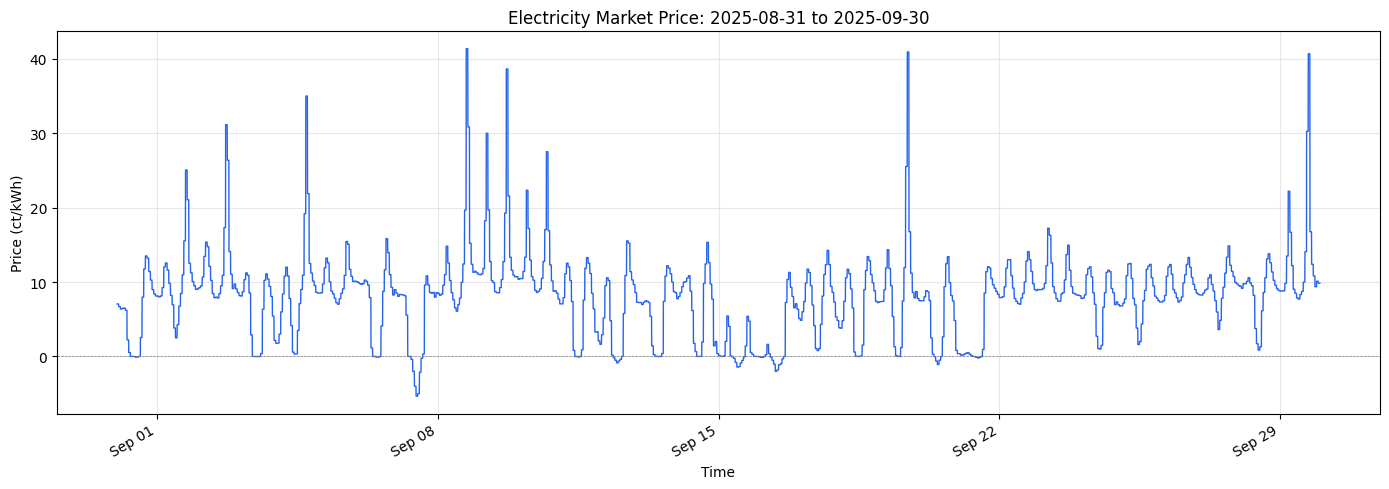

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))

show_price = "baseprice" # "baseprice" or "price_normalized" or "marketprice"
ax.plot(df_plot["start"], df_plot[show_price], linewidth=1.0, color="#2563eb")
# ax.fill_between(df_plot["start"], df_plot[show_price], alpha=0.15, color="#2563eb")

ax.set_xlabel("Time")
ax.set_ylabel(f"Price ({unit})")
ax.set_title(f"Electricity Market Price: {start.date()} to {end.date()}")

# Format x-axis based on duration
duration = end - start
if duration <= timedelta(hours=48):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
elif duration <= timedelta(days=14):
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
else:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()